In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

df.shape

df.info()

df.describe()

df.isnull().sum()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.info()

df.isnull().sum()

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

(7043, 21)

## Data Cleaning

In [2]:
# Check missing values after converting TotalCharge
df.isnull().sum()

# Remove rows with missing TotalCharges values
df = df.dropna()

# Check shape after removing missing values
df.shape

# Check missing values again
df.isnull().sum()



customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Target Variable Distribution

In [3]:
df["Churn"].value_counts()

df["Churn"].value_counts(normalize=True) * 100


Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

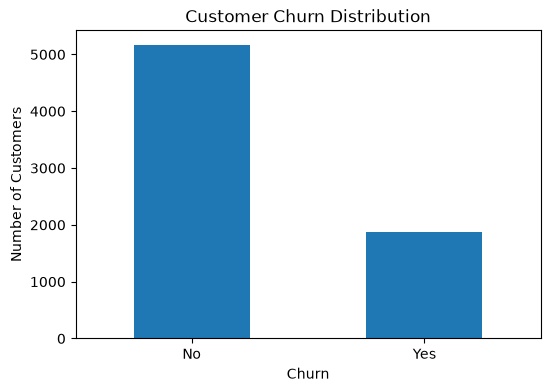

In [4]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))
churn_counts.plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The number of customers who did not churn is more than the number of customers who churned in the dataset. This shows that the target variable is not balanced. Because of this imbalance, accuracy alone may not be enough to evaluate the models. Metrics such as precision, recall and F1-score will also be used.

In [5]:
df = df.drop("customerID", axis=1)
df.head()

df.info()

df.shape
df["Churn"].value_counts()
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   str    
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   str    
 3   Dependents        7032 non-null   str    
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  Contract          7032 non-null   str    
 15  PaperlessBilling  7032 non-null   str    
 16  PaymentMethod     7032 non-null   str    
 17  MonthlyChar

## Exploratory Data Analytisis

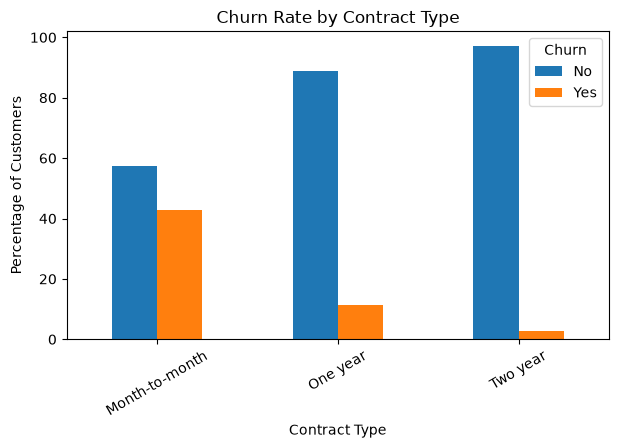

In [6]:
# Contract type and churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn.plot(kind="bar", figsize=(7, 4))
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=30)
plt.legend(title="Churn")
plt.show()

The chart shows that customers with one year or two year type of contracts have less churn rate than customers with month to month contracts. This can be considered as contract type plays important role in predicting customer churn.

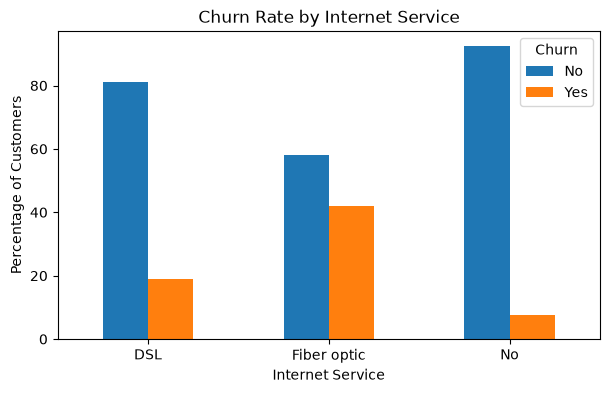

In [7]:
# Internet service and churn
internet_churn = pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

internet_churn.plot(kind="bar", figsize=(7, 4))
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

Churn Rate is shown for different internet service types in the above-mentioned graph. This allows to understand if there are service types whose customers are more likely to leaving the company.

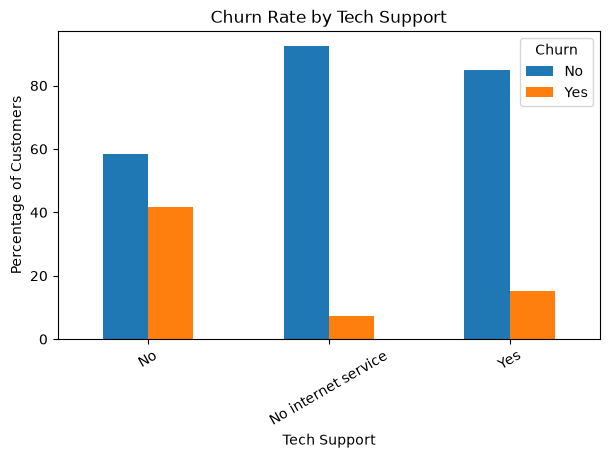

In [8]:
# Tech support and churn
tech_churn = pd.crosstab(df["TechSupport"], df["Churn"], normalize="index") * 100

tech_churn.plot(kind="bar", figsize=(7, 4))
plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=30)
plt.legend(title="Churn")
plt.show()

Customers without tech support seem to have a higher churn rate. Therefore, support services could somehow be connected to customer retention.

<Figure size 700x400 with 0 Axes>

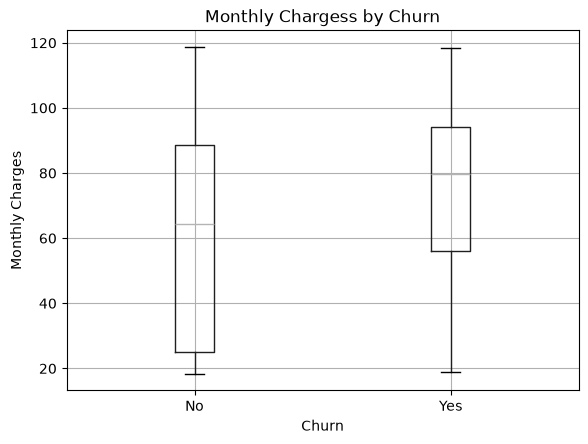

In [9]:
# Monthly charges by churn
plt.figure(figsize=(7, 4))
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Chargess by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

This graph displays the distribution of monthly charges among those who churned and those who didn’t churn. This graph can be used to confirm if high monthly charges have an effect on churn rate.

<Figure size 700x400 with 0 Axes>

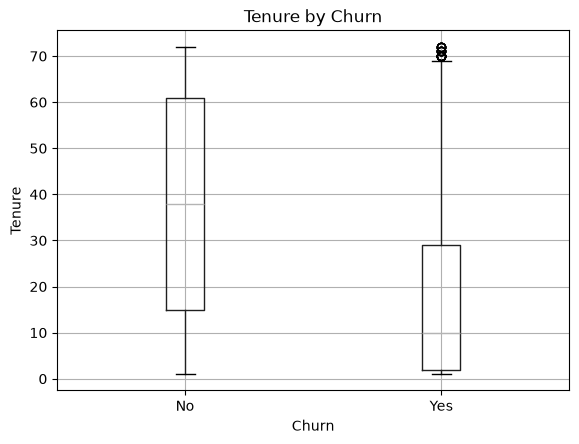

In [10]:
# Tenure by churn
plt.figure(figsize=(7, 4))
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()
 

This graph represents the connection between customer tenure and churn rates. The customers who have lower tenure tend to churn, so that new customers might need better retention strategies.

In [11]:
# Fresh dataset for machine learning
ml_df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean column names
ml_df.columns = ml_df.columns.str.strip()

# Convert TotalCharges to numeric
ml_df["TotalCharges"] = pd.to_numeric(ml_df["TotalCharges"], errors="coerce")

# Remove missing values from TotalCharges
ml_df = ml_df.dropna()

# Drop customerID because it is only an identifier
ml_df = ml_df.drop("customerID", axis=1, errors="ignore")

# Clean and convert Churn target
ml_df["Churn"] = ml_df["Churn"].astype(str).str.strip()
print("Unique Churn values before mapping:", ml_df["Churn"].unique())

ml_df["Churn"] = ml_df["Churn"].map({"Yes": 1, "No": 0})

# Check if Churn has missing values
print("Missing values in Churn:", ml_df["Churn"].isnull().sum())
print(ml_df["Churn"].value_counts(dropna=False))

Unique Churn values before mapping: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Missing values in Churn: 0
Churn
0    5163
1    1869
Name: count, dtype: int64


# Preprocessssing for Machine Learning

In [12]:
# Separate features and target
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

# Convert categorical variables into dummy variables
X = pd.get_dummies(X, drop_first=True)

# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing completed")

Training set: (5625, 30)
Testing set: (1407, 30)
Preprocessing completed


## Model Development

In [13]:
# Create machine learning models
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
decision_tree = DecisionTreeClassifier(class_weight="balanced", random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

# Train the models
log_reg.fit(X_train_scaled, y_train)
decision_tree.fit(X_train_scaled, y_train)
random_forest.fit(X_train_scaled, y_train)

print("Models trained successfully")

Models trained successfully


Three models have been created using machine learning algorithms including logistic regression, decision tree and random forest. This is because the models are applicable in binary classification problems. The reason why the class_weight="balanced" parameter was used because the dataset contains more non-churn customers than churn customers.

## Model Evaluation

In [14]:
# Function to evaluate model performance
def evaluate_model(model, X_test_data, y_test, model_name):
    y_pred = model.predict(X_test_data)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

# Evaluate all models
results = []

results.append(evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression"))
results.append(evaluate_model(decision_tree, X_test_scaled, y_test, "Decision Tree"))
results.append(evaluate_model(random_forest, X_test_scaled, y_test, "Random Forest"))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.726368,0.490939,0.796791,0.607543
1,Decision Tree,0.729211,0.490566,0.486631,0.488591
2,Random Forest,0.766880,0.550885,0.665775,0.602906


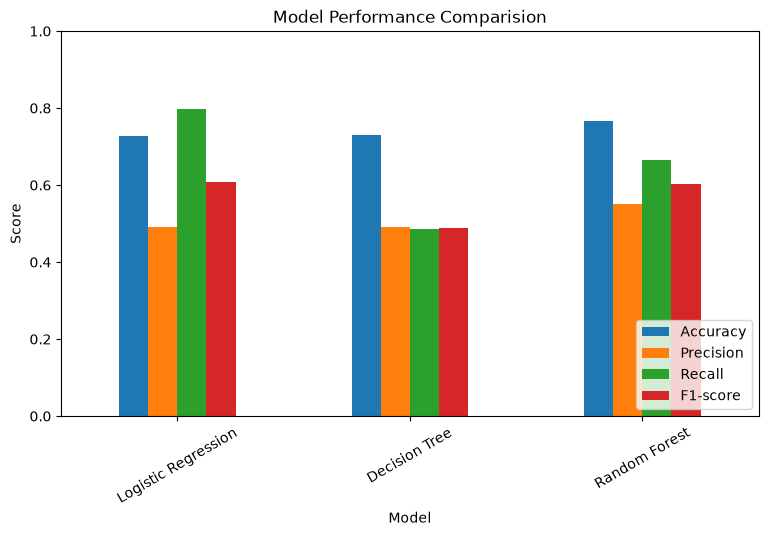

In [15]:
# Model performance comparison
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparision")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.show()

In [16]:
# Classification reports for all models
models = {
    "Logitic Regression": log_reg,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

for name, model in models.items():
    print(name)
    print(classification_report(y_test, model.predict(X_test_scaled)))
    print("-" * 50)

Logitic Regression
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

--------------------------------------------------
Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1033
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407

--------------------------------------------------
Random Forest
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1033
           1       0.55      0.67      0.60       374

    accuracy                     

In [17]:
# Confusion matrice for all models
for name, model in models.items():
    print(name)
    print(confusion_matrix(y_test, model.predict(X_test_scaled)))
    print("-" * 50)

Logitic Regression
[[724 309]
 [ 76 298]]
--------------------------------------------------
Decision Tree
[[844 189]
 [192 182]]
--------------------------------------------------
Random Forest
[[830 203]
 [125 249]]
--------------------------------------------------


## Model Selection

However, Logistic Regression achieved the highest recall and F1-score. In terms of predicting customer churn, recall plays an important role since the company needs to predict as many potential churn customers as possible. The absence of churn customers might decrease the probability of conducting early retention actions.

Therefore, Logistic Regression can be considered as the most valuable model, whereas Random Forest can be evaluated as the best-performing one in terms of overall accuracy and precision.

## Feature Importance and Business Recommendations

In [18]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.171313
1,tenure,0.167531
2,MonthlyCharges,0.154535
25,Contract_Two year,0.061437
10,InternetService_Fiber optic,0.040453
28,PaymentMethod_Electronic check,0.036361
24,Contract_One year,0.032076
13,OnlineSecurity_Yes,0.031198
4,gender_Male,0.025567
19,TechSupport_Yes,0.023545


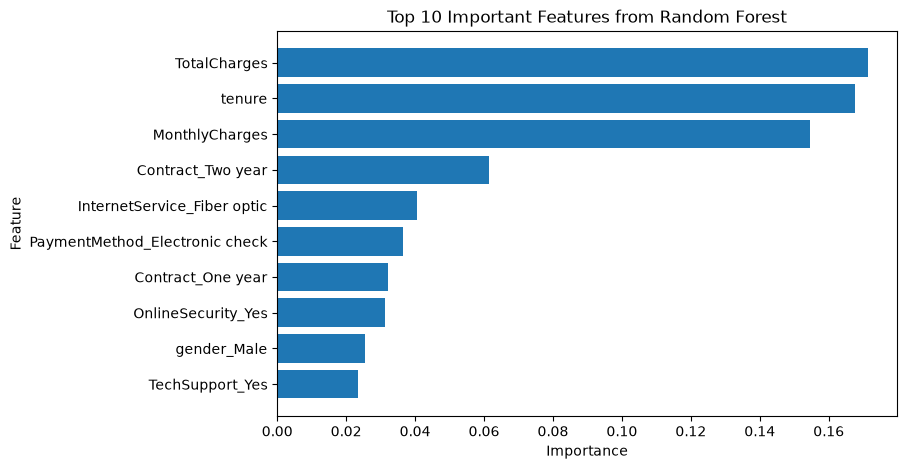

In [19]:
# Plot top 10 important features
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 10 Important Features from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Based on the feature importance outcomes, we learn about the features that had significant influence on the prediction of the Random Forest algorithm. These features are useful for the company to know what features of their customers or services influence the probability of churn the most. The findings can be helpful for implementing retention strategies, such as working with risky contracts and expensive charges.

In [20]:
# Logistic Regression coefficients
log_reg_features = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

log_reg_features["Absolute Coefficient"] = log_reg_features["Coefficient"].abs()

log_reg_features = log_reg_features.sort_values(
    by = "Absolute Coefficient", ascending=False
)

log_reg_features.head(10)

,Feature,Coefficient,Absolute Coefficient
1,tenure,-1.263854,1.263854
2,MonthlyCharges,-0.928682,0.928682
10,InternetService_Fiber optic,0.746144,0.746144
25,Contract_Two year,-0.638598,0.638598
3,TotalCharges,0.623279,0.623279
24,Contract_One year,-0.326693,0.326693
21,StreamingTV_Yes,0.259691,0.259691
23,StreamingMovies_Yes,0.252870,0.252870
9,MultipleLines_Yes,0.202763,0.202763
28,PaymentMethod_Electronic check,0.193697,0.193697


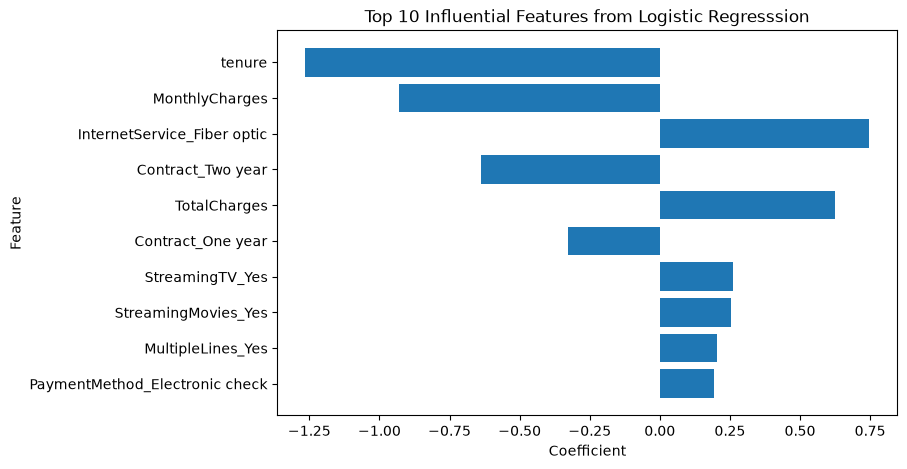

In [21]:
# Plot top 10 Logistic Regression coefficients
top_log_features = log_reg_features.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_log_features["Feature"], top_log_features["Coefficient"])
plt.title("Top 10 Influential Features from Logistic Regresssion")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

The Logistic Regression Coefficients are useful in explaining how different variables affect the model in terms of the prediction of the churn. The positive coefficients indicate that the probability of the customer churning is increased, while the negative coefficients indicate that the probability of the customer churning is decreased. This supports the interpretability of the project because the results can be linked back to business decision-making.

## Conclusion

Tree machine learning models, which are Logistic Regression,  Decision Tree, and Random Forest, were developed and compared for customer churn prediction in this project. Based on the results, Random Forest achieved the best overall accuracy and precision, and Logistic Regressssion achieved the best recall and F1-score. Since recall plays an important role in churn prediction, Logistic Regression is useful for predicting which customers are more likely to leave in the future. 

As follows from exploratory data analysis and feature importance results, customer behavior, contract, tenure, monthly charge, and other service related features might play an important role in predicting churn. Such results will help in creating effective retention strategy for the company.